## 
Plots 
Alaska extRemes analysis on TXx

'Loc & scale: time':  location.fun= ~ glost, scale.fun = ~glost <br>

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import scipy
import cftime
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as colors
import cmaps
import geopandas as gpd

import matplotlib.colors as mcolors


In [2]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

In [3]:
import warnings
warnings.filterwarnings('ignore')

# READ EVGAM output FILES

In [ ]:
yearb=1941
yeare=2025
lon_min = 235
lon_max = 293
lat_min = 25
lat_max = 50

dirin =''

dsj = xr.open_dataset('era5_Summer_snowd_mask.nc')

ds0 = xr.open_dataset(f'{dirin}/TXx_Alaska_ij_LocScaglost_extremes5droll_1941_2025.nc')
dsj = dsj.sel(lon=ds0['lon'],lat=ds0['lat'])
maskSd = dsj['maskSd']
ds0=ds0.where(maskSd==1)
rl1000 = ds0['rl100']
loc0 = ds0['location'] 
scale0 = ds0['scale'] 
shape0 = ds0['shape'] 
#LocationDiff_q0 = ds0['LocationDiff_q']
#ScaleDiff_q0 = ds0['ScaleDiff_q']
##RLDiff_q0 = ds0['RLDiff_q']
##RiskRatios_q0 = ds0['RiskRatios_q']
#CRPS0 = ds0['CRPS']
#DawSeb0 = ds0['DawSeb']
#SE0 = ds0['SE']
#KS_D0 = ds0['KS_D']
#KS_pvalue0 = ds0['KS_pvalue']
#CVM_D0 = ds0['CVM_D']
#CVM_pvalue0 = ds0['CVM_pvalue']

units = '°F'

Tlabels = ['Loc & scale: glost']


# Scores & tests

In [5]:
proj=ccrs.PlateCarree()

In [6]:
import cmaps
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import matplotlib as mpl

# Define colors (names, hex codes, or RGB tuples)
B_colors =["xkcd:periwinkle","darkblue","blue","xkcd:electric blue","xkcd:lightish blue",\
           "xkcd:sky blue","xkcd:powder blue","aliceblue"]
# Create a smooth gradient colormap
Blues_map = mcolors.LinearSegmentedColormap.from_list("my_gradient", B_colors)

# Define colors (names, hex codes, or RGB tuples)
R_colors = ["lightyellow","yellow","gold",  "darkorange","xkcd:blood orange",\
            "xkcd:red","darkred","xkcd:peachy pink"]
# Create a smooth gradient colormap
Reds_map = mcolors.LinearSegmentedColormap.from_list("my_gradient", R_colors)
BR_map = ListedColormap(np.vstack((Blues_map.resampled(128)(np.linspace(0, 1, 128)),Reds_map.resampled(128)(np.linspace(0, 1, 128)))))

# PLOT Return Level 100

Text(0.5, 0.98, '100-year Return Level / 1% AEP Level')

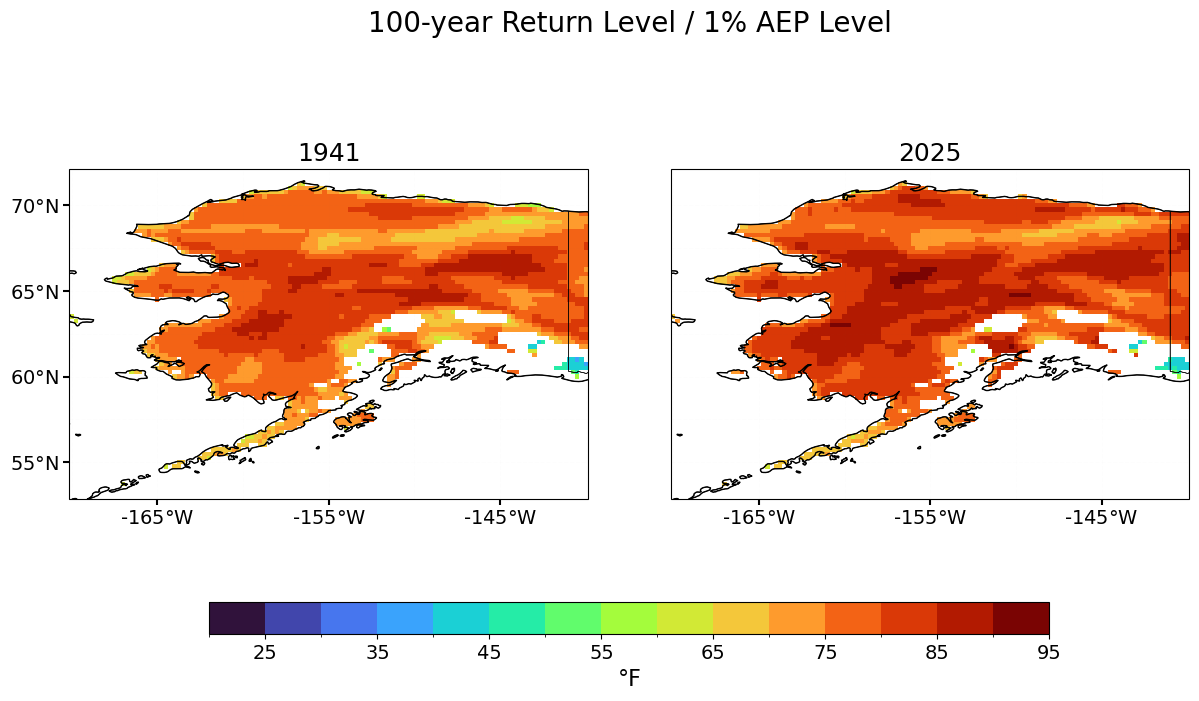

In [7]:
clevs = np.arange(20,100,5)
cmap = plt.get_cmap('turbo',len(clevs)-1).copy()

proj=ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.16)
cc = rl1000.sel(time=yearb).plot.pcolormesh(ax=ax[0],cmap=cmap,levels=clevs,add_colorbar=False)
ax[0].set_title(yearb,fontsize=18)    
rl1000.sel(time=yeare).plot.pcolormesh(ax=ax[1],cmap=cmap,levels=clevs,add_colorbar=False)
ax[1].set_title(yeare,fontsize=18)    

####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_xticks(ax[ix].get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

for ix in range(0,1): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',ticks=clevs[1::2])
cbar.set_label(label=units,fontsize=16)
cbar.ax.tick_params(labelsize=14)  
plt.suptitle(f'100-year Return Level / 1% AEP Level',fontsize=20)  

Text(0.5, 0.98, '100-year Return Level / 1% AEP Level,\n Difference 2025 - 1941')

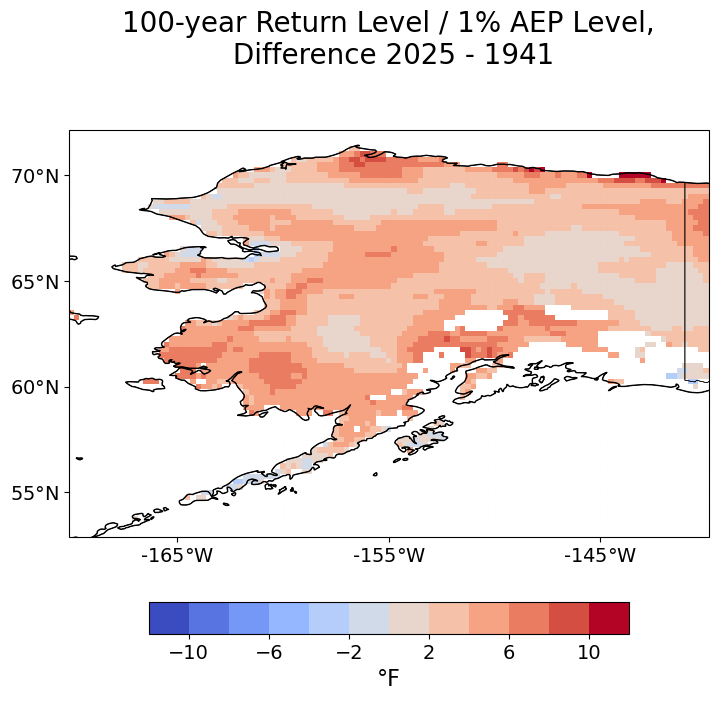

In [8]:
clevs = np.arange(-12,14,2)
cmap = plt.get_cmap('coolwarm',len(clevs)-1).copy()

proj=ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(8,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.16)
cc = (rl1000.sel(time=yeare)-rl1000.sel(time=yearb)).plot.pcolormesh(ax=ax,cmap=cmap,vmin=clevs[0],vmax=clevs[-1],add_colorbar=False)

####
grd = ax.gridlines(
  draw_labels=False, 
  color='gray', alpha=0.01, linestyle='--')

ax.set_xlabel('')
ax.set_ylabel('')
ax.add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
ax.coastlines()
ax.set_xticks(ax.get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
ax.set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax.get_xticks()],size=14)
ax.set_title(f'',fontsize=18)    
ax.set_yticks(ax.get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
ax.set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax.get_yticks()],size=14)
#
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',ticks=clevs[1::2])
cbar.set_label(label=units,fontsize=16)
cbar.ax.tick_params(labelsize=14)  
plt.suptitle(f'100-year Return Level / 1% AEP Level,\n Difference {yeare} - {yearb}',fontsize=20)  

Text(0.5, 0.98, 'Location parameter')

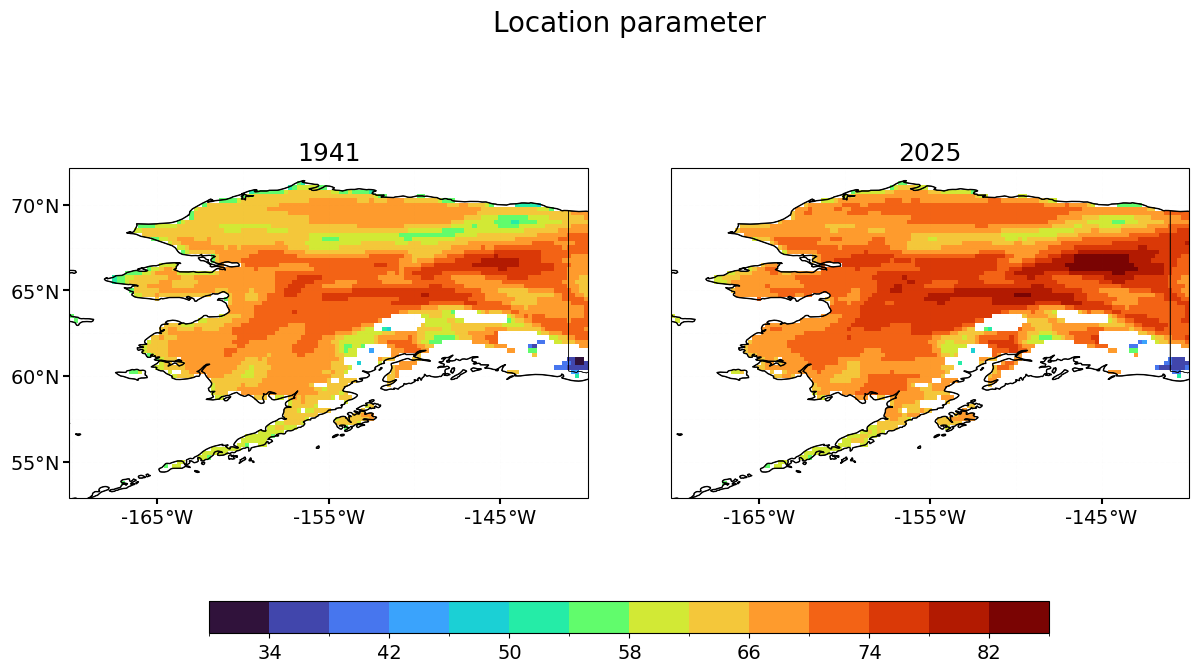

In [9]:
clevs = np.arange(30,88,4)
cmap = plt.get_cmap('turbo',len(clevs)).copy()

proj=ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.16)
cc = loc0.sel(time=yearb).plot.pcolormesh(ax=ax[0],cmap=cmap,levels=clevs,add_colorbar=False)
ax[0].set_title(yearb,fontsize=18)    
loc0.sel(time=yeare).plot.pcolormesh(ax=ax[1],cmap=cmap,levels=clevs,add_colorbar=False)
ax[1].set_title(yeare,fontsize=18)    

####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_xticks(ax[ix].get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

for ix in range(0,1): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',ticks=clevs[1::2])
cbar.set_label(label='',fontsize=16)
cbar.ax.tick_params(labelsize=14)  
plt.suptitle(f'Location parameter',fontsize=20)  

Text(0.5, 0.98, 'Scale parameter')

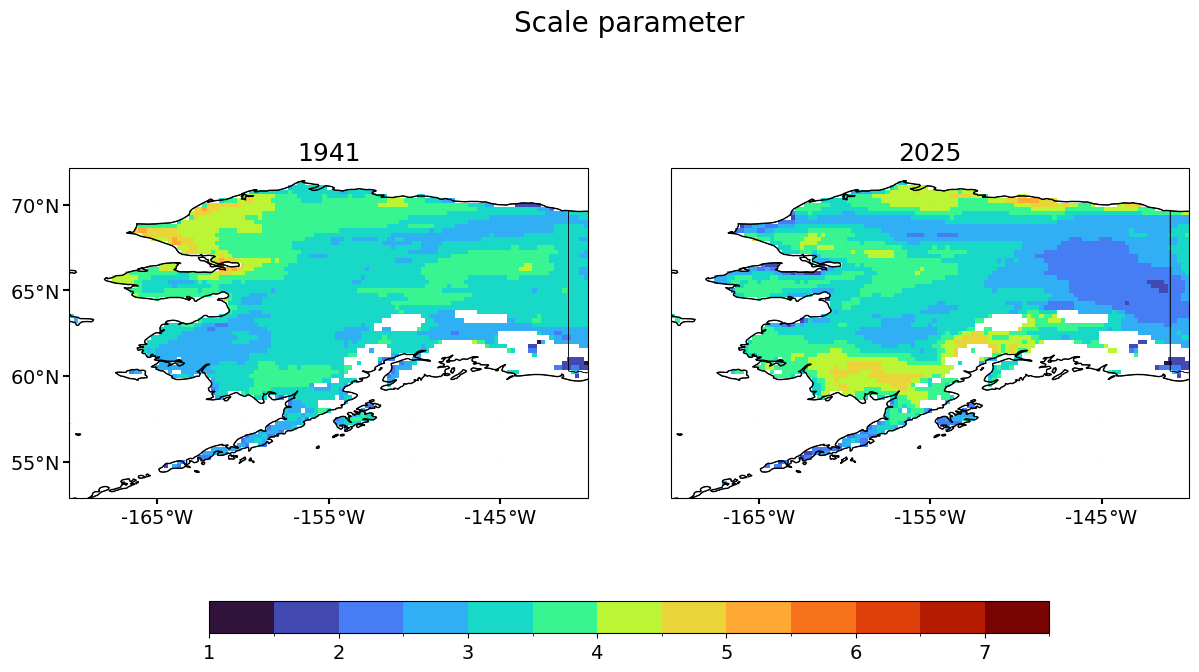

In [10]:
clevs = np.arange(1,8,0.5)
cmap = plt.get_cmap('turbo',len(clevs)).copy()

proj=ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.16)
cc = scale0.sel(time=yearb).plot.pcolormesh(ax=ax[0],cmap=cmap,levels=clevs,add_colorbar=False)
ax[0].set_title(yearb,fontsize=18)    
scale0.sel(time=yeare).plot.pcolormesh(ax=ax[1],cmap=cmap,levels=clevs,add_colorbar=False)
ax[1].set_title(yeare,fontsize=18)    

####
for ix in range(0,len(ax)):
  grd = ax[ix].gridlines(
    draw_labels=False, 
    color='gray', alpha=0.01, linestyle='--')
  ax[ix].set_xlabel('')
  ax[ix].set_ylabel('')
  ax[ix].add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
  ax[ix].tick_params(axis='both',direction='out',width=1.5,length=4)
  ax[ix].set_xticks(ax[ix].get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax[ix].get_xticks()],size=14)
  ax[ix].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
  ax[ix].coastlines()

for ix in range(0,1): 
  ax[ix].set_yticks(ax[ix].get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
  ax[ix].set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax[ix].get_yticks()],size=14)
#
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',ticks=clevs[::2])
cbar.set_label(label='',fontsize=16)
cbar.ax.tick_params(labelsize=14)  
plt.suptitle(f'Scale parameter',fontsize=20)  

Text(0.5, 0.98, 'Shape parameter')

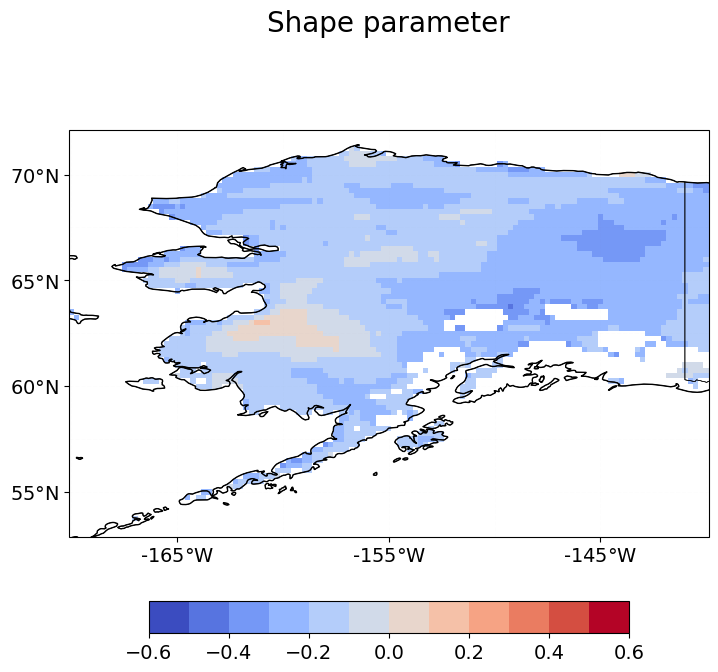

In [11]:
clevs = np.arange(-0.6,0.7,0.1)
cmap = plt.get_cmap('coolwarm',len(clevs)-1).copy()

proj=ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(8,8),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.25,left=0.1, right=0.9,top=0.9,hspace=0.04,wspace=0.16)
cc = shape0.sel(time=yeare).plot.pcolormesh(ax=ax,cmap=cmap,vmin=clevs[0],vmax=clevs[-1],add_colorbar=False)

####
grd = ax.gridlines(
  draw_labels=False, 
  color='gray', alpha=0.01, linestyle='--')

ax.set_xlabel('')
ax.set_ylabel('')
ax.add_feature(state_borders,zorder=100,linewidth=0.4,edgecolor='k')
ax.add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.15) 
ax.coastlines()
ax.set_xticks(ax.get_xticks()[2:-1:2],crs=ccrs.PlateCarree())
ax.set_xticklabels([f'{round(ixx)}$\degree$W' for ixx in ax.get_xticks()],size=14)
ax.set_title(f'',fontsize=18)    
ax.set_yticks(ax.get_yticks()[1:-1:2],crs=ccrs.PlateCarree())
ax.set_yticklabels([f'{round(ixx)}$\degree$N' for ixx in ax.get_yticks()],size=14)
#
#
ax_cbar = fig.add_axes([0.2, 0.2, 0.6, 0.04])
cbar=fig.colorbar(cc,cax=ax_cbar,shrink=0.5,orientation='horizontal',ticks=clevs[::2])
cbar.ax.tick_params(labelsize=14)  
plt.suptitle(f'Shape parameter',fontsize=20)  